# Software Development Trends in Algeria

This notebook tracks GitHub software-development activity in Algeria over time and compares Algeria with the same peer groups used in the AI adoption notebook:

- Structural peers: Ecuador, Peru, Ghana, Vietnam, Colombia.
- Regional peers: Egypt, Jordan, Morocco, Tunisia, Iraq.
- Aspirational peers: Malaysia, Chile, Poland, Romania.

The analysis uses quarterly GitHub Innovation Graph data stored locally under `data/github` and annual population statistics from the World Bank `SP.POP.1564.TO` indicator.

## Setup

In [60]:
from pathlib import Path
from urllib.request import urlopen
import json

import altair as alt
import pandas as pd
import pycountry
import attaviz

attaviz.enable()
alt.data_transformers.enable("default", max_rows=None)

DataTransformerRegistry.enable('default')

In [61]:
def find_project_root(marker="pyproject.toml"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
GITHUB_DIR = DATA_DIR / "github"

COUNTRY_CODE = "DZ"
COUNTRY_NAME = "Algeria"

PEER_GROUPS = {
    "Structural": ["EC", "PE", "GH", "VN", "CO"],
    "Regional": ["EG", "JO", "MA", "TN", "IQ"],
    "Aspirational": ["MY", "CL", "PL", "RO"],
    "Developers":['EG', 'NG', 'KE', 'MA']
}

COUNTRY_NAMES = {
    "DZ": "Algeria",
    "EG": "Egypt",
    "JO": "Jordan",
    "MA": "Morocco",
    "TN": "Tunisia",
    "IQ": "Iraq",
    "EC": "Ecuador",
    "PE": "Peru",
    "GH": "Ghana",
    "VN": "Vietnam",
    "CO": "Colombia",
    "MY": "Malaysia",
    "CL": "Chile",
    "PL": "Poland",
    "RO": "Romania",
}

PEER_CODES = [COUNTRY_CODE] + [code for codes in PEER_GROUPS.values() for code in codes]
ALGERIA_COLOR = "#0071BC"
PEER_COLORS = ["#8A969F", "#9FA8AF", "#B0B8BE", "#C1C8CD", "#D2D7DB"]

ISO2_TO_ISO3 = {
    "DZ": "DZA",
    "EG": "EGY",
    "JO": "JOR",
    "MA": "MAR",
    "TN": "TUN",
    "IQ": "IRQ",
    "EC": "ECU",
    "PE": "PER",
    "GH": "GHA",
    "VN": "VNM",
    "CO": "COL",
    "MY": "MYS",
    "CL": "CHL",
    "PL": "POL",
    "RO": "ROU",
}
ISO3_TO_ISO2 = {iso3: iso2 for iso2, iso3 in ISO2_TO_ISO3.items()}

def country_name_from_iso2(code: str) -> str:
    if code == "EU":
        return "European Union"
    if code in COUNTRY_NAMES:
        return COUNTRY_NAMES[code]
    country = pycountry.countries.get(alpha_2=code)
    return country.name if country else code


## Data

In [62]:
import ssl


def iso2_to_iso3(code: str) -> str | None:
    if code in ISO2_TO_ISO3:
        return ISO2_TO_ISO3[code]
    country = pycountry.countries.get(alpha_2=code)
    return country.alpha_3 if country else None


def load_world_bank_population(iso2_codes: list[str]) -> pd.DataFrame:
    iso_map = {code: iso2_to_iso3(code) for code in sorted(set(iso2_codes)) if isinstance(code, str)}
    iso_map = {iso2: iso3 for iso2, iso3 in iso_map.items() if iso3 is not None}
    iso3_to_iso2 = {iso3: iso2 for iso2, iso3 in iso_map.items()}

    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    # Fetch all World Bank economies once, then filter locally. This avoids one
    # unsupported GitHub ISO code making an entire batched API request empty.
    url = (
        "https://api.worldbank.org/v2/country/all"
        "/indicator/SP.POP.1564.TO?format=json&per_page=20000"
    )
    with urlopen(url, context=ctx) as response:
        payload = json.load(response)

    records = payload[1] if len(payload) > 1 and payload[1] else []
    if not records:
        raise ValueError(
            "World Bank API returned no SP.POP.1564.TO records. "
            "Check network access or the indicator endpoint."
        )

    population = pd.DataFrame(records)
    required_cols = ["countryiso3code", "date", "value"]
    missing_cols = [col for col in required_cols if col not in population.columns]
    if missing_cols:
        raise ValueError(
            f"World Bank API response is missing expected columns: {missing_cols}. "
            f"Available columns: {population.columns.tolist()}"
        )

    return (
        population.loc[:, required_cols]
        .rename(
            columns={
                "countryiso3code": "iso3_code",
                "date": "year",
                "value": "working_age_population",
            }
        )
        .dropna(subset=["working_age_population"])
        .assign(
            iso2_code=lambda d: d["iso3_code"].map(iso3_to_iso2),
            year=lambda d: d["year"].astype(int),
            working_age_population=lambda d: d["working_age_population"].astype(float),
            population=lambda d: d["working_age_population"].astype(float),
        )
        .dropna(subset=["iso2_code"])
        .sort_values(["iso2_code", "year"])
    )

def attach_latest_population(github_df: pd.DataFrame, population_df: pd.DataFrame) -> pd.DataFrame:
    pieces = []
    for iso2_code, country_df in github_df.sort_values("year").groupby("iso2_code", sort=False):
        pop_country = population_df.loc[population_df["iso2_code"] == iso2_code].sort_values("year")
        if pop_country.empty:
            continue
        pieces.append(
            pd.merge_asof(
                country_df.sort_values("year"),
                pop_country[["year", "working_age_population", "population"]],
                on="year",
                direction="backward",
            )
        )
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()


def get_index(
    df: pd.DataFrame,
    working_age_df: pd.DataFrame,
    measure: str,
    global_data: pd.DataFrame | None = None,
    country_code: str | None = None,
) -> pd.DataFrame:
    # Adds share-of-activity / share-of-working-age-population index.
    # For each quarter: (country measure / global measure) /
    # (country working-age population / global working-age population).
    data = df.copy()
    global_df = data if global_data is None else global_data.copy()

    if "working_age_population" not in data.columns:
        data = attach_latest_population(data, working_age_df)
    if "working_age_population" not in global_df.columns:
        global_df = attach_latest_population(global_df, working_age_df)

    if country_code is not None:
        data = data.loc[data["iso2_code"] == country_code].copy()

    totals = (
        global_df.dropna(subset=[measure, "working_age_population"])
        .groupby(["year", "quarter"], as_index=False)
        .agg(
            global_measure=(measure, "sum"),
            global_working_age_population=("working_age_population", "sum"),
        )
    )

    index_col = f"{measure}_index"
    return (
        data.merge(totals, on=["year", "quarter"], how="left")
        .assign(
            **{
                index_col: lambda d: (
                    (d[measure] / d["global_measure"])
                    / (d["working_age_population"] / d["global_working_age_population"])
                )
            }
        )
        .drop(columns=["global_measure", "global_working_age_population"])
    )


def load_github_metric(metric: str, population_df: pd.DataFrame, peer_codes: list[str] = PEER_CODES) -> pd.DataFrame:
    raw = (
        pd.read_csv(GITHUB_DIR / f"{metric}.csv")
        .dropna(subset=["iso2_code"])
        .loc[lambda d: d["iso2_code"] != "EU"]
        .assign(
            iso2_code=lambda d: d["iso2_code"].astype(str),
            quarter_start=lambda d: pd.PeriodIndex(
                d["year"].astype(str) + "Q" + d["quarter"].astype(str), freq="Q"
            ).to_timestamp(),
        )
        .sort_values(["iso2_code", "year", "quarter"])
    )

    raw_with_population = attach_latest_population(raw, population_df)
    per_100k_col = f"{metric}_per_100k"
    indexed = (
        get_index(raw_with_population, population_df, metric, global_data=raw_with_population)
        .assign(**{per_100k_col: lambda d: d[metric] / d["working_age_population"] * 100_000})
        .dropna(subset=[per_100k_col, f"{metric}_index"])
    )

    return (
        indexed.loc[lambda d: d["iso2_code"].isin(peer_codes)]
        .assign(country_name=lambda d: d["iso2_code"].map(COUNTRY_NAMES))
        .sort_values(["iso2_code", "year", "quarter"])
    )


github_metric_codes = sorted(
    set().union(
        *[
            set(pd.read_csv(GITHUB_DIR / f"{metric}.csv")["iso2_code"].dropna().astype(str))
            for metric in ["developers", "repositories", "organizations", "git_pushes"]
        ]
    )
    - {"EU"}
)
working_age_population = load_world_bank_population(github_metric_codes)
population = working_age_population

developers = load_github_metric("developers", working_age_population)
repositories = load_github_metric("repositories", working_age_population)
organizations = load_github_metric("organizations", working_age_population)
git_pushes = load_github_metric("git_pushes", working_age_population)

metric_frames = {
    "developers": developers,
    "repositories": repositories,
    "organizations": organizations,
    "git_pushes": git_pushes,
}
for metric_name, metric_df in metric_frames.items():
    if metric_df.empty:
        raise ValueError(f"{metric_name} is empty after merging GitHub data with working-age population.")
    missing_peers = sorted(set(PEER_CODES) - set(metric_df["iso2_code"]))
    if missing_peers:
        raise ValueError(f"{metric_name} is missing peer countries after population merge: {missing_peers}")

algeria_trend = developers.loc[developers["iso2_code"] == COUNTRY_CODE].copy()
algeria_summary = {
    "first_quarter": f"{int(algeria_trend.iloc[0]['year'])} Q{int(algeria_trend.iloc[0]['quarter'])}",
    "last_quarter": f"{int(algeria_trend.iloc[-1]['year'])} Q{int(algeria_trend.iloc[-1]['quarter'])}",
    "first_developers_per_100k": algeria_trend.iloc[0]["developers_per_100k"],
    "last_developers_per_100k": algeria_trend.iloc[-1]["developers_per_100k"],
    "last_developers_index": algeria_trend.iloc[-1]["developers_index"],
}

algeria_summary

{'first_quarter': '2020 Q1',
 'last_quarter': '2025 Q4',
 'first_developers_per_100k': np.float64(329.54274889308397),
 'last_developers_per_100k': np.float64(1804.2682649560209),
 'last_developers_index': np.float64(0.5368444416157475)}

## GitHub Developers Per 100k People Over Time

Algeria's visible GitHub developer base grew substantially in per-capita terms over the Innovation Graph period. The panels below compare Algeria with each peer group separately, using annual World Bank population statistics to express quarterly GitHub developer counts as developers per 100k people.

In [68]:
INDEX_MEASURE = True

# Annotation dictionary: date (as pandas.Timestamp) -> label
ANNOTATIONS = {
    pd.Timestamp('2024-12-15'): 'Free access to GitHub Copilot',  # 2024 Q4
}

def make_peer_trend_panel(
    data: pd.DataFrame,
    raw_col: str,
    value_col: str,
    group_name: str,
    y_axis_title: str,
    width: int = 150,
    height: int = 100,
    show_y_title: bool = False,
    value_format: str = ",.0f",
    parity_at: float | None = None,
    annotations: dict = ANNOTATIONS,
) -> alt.Chart:
    codes = [COUNTRY_CODE] + PEER_GROUPS[group_name]
    d = data.loc[data["iso2_code"].isin(codes)].copy()
    latest_quarter = d["quarter_start"].max()
    labels = d.loc[d["quarter_start"] == latest_quarter].copy()

    color_domain = [COUNTRY_NAMES[code] for code in codes]
    color_range = [ALGERIA_COLOR] + PEER_COLORS[: len(codes) - 1]
    y_title = y_axis_title if show_y_title else None

    base = alt.Chart(d).encode(
        x=alt.X("quarter_start:T", title=None),
        y=alt.Y(
            f"{value_col}:Q",
            title=y_title,
            axis=alt.Axis(format="~s"),
            scale=alt.Scale(zero=True),
        ),
        color=alt.Color(
            "country_name:N",
            title=None,
            scale=alt.Scale(domain=color_domain, range=color_range),
            legend=None,
        ),
        detail="country_name:N",
    )

    lines = base.mark_line().encode(
        strokeWidth=alt.condition(
            alt.datum.iso2_code == COUNTRY_CODE, alt.value(4), alt.value(2)
        ),
        opacity=alt.condition(
            alt.datum.iso2_code == COUNTRY_CODE, alt.value(1.0), alt.value(0.72)
        ),
        tooltip=[
            alt.Tooltip("country_name:N", title="Country"),
            alt.Tooltip("year:O", title="Year"),
            alt.Tooltip("quarter:O", title="Quarter"),
            alt.Tooltip(f"{value_col}:Q", title=y_axis_title, format=value_format),
            alt.Tooltip(f"{raw_col}:Q", title=raw_col.replace("_", " " ).title(), format=","),
            alt.Tooltip("working_age_population:Q", title="Working-age population", format=",.0f"),
        ],
    )

    points = base.transform_filter(alt.datum.iso2_code == COUNTRY_CODE).mark_point(
        size=38, filled=True, stroke="white", strokeWidth=1
    )

    latest_labels = (
        alt.Chart(labels)
        .mark_text(align="left", baseline="middle", dx=6, fontSize=11)
        .encode(
            x=alt.X("quarter_start:T"),
            y=alt.Y(f"{value_col}:Q"),
            text="country_name:N",
            color=alt.Color(
                "country_name:N",
                scale=alt.Scale(domain=color_domain, range=color_range),
                legend=None,
            ),
        )
    )

    layers = [lines, points, latest_labels]
    if parity_at is not None:
        layers.append(
            alt.Chart(pd.DataFrame({"y": [parity_at]}))
            .mark_rule(color="#888", strokeDash=[4, 3])
            .encode(y="y:Q")
        )

    # Add annotation lines and text if provided
    if annotations:
        for date, label in annotations.items():
            layers.append(
                alt.Chart(pd.DataFrame({"quarter_start": [date]}))
                .mark_rule(color="#D62728", strokeDash=[6, 3])
                .encode(x="quarter_start:T")
            )
            layers.append(
                alt.Chart(pd.DataFrame({"quarter_start": [date], "label": [label]}))
                .mark_text(align="left", dx=6, dy=-8, fontSize=10, color="#D62728")
                .encode(x="quarter_start:T", y=alt.value(0), text="label:N")
            )

    return alt.layer(*layers).properties(
        width=width,
        height=height,
        title=alt.Title(
            text=f"{group_name} peers",
            anchor="start",
            fontSize=12,
            subtitleFontSize=10,
            offset=8,
        ),
    )


def make_three_peer_trends(
    data: pd.DataFrame,
    raw_col: str,
    metric_label: str,
    index_measure: bool = False,
) -> alt.Chart:
    if index_measure:
        value_col = f"{raw_col}_index"
        y_axis_title = f"{metric_label} index"
        value_format = ",.2f"
        parity_at = 1.0
        title = f"GitHub {metric_label} Index in Algeria and Peer Countries"
        subtitle = "Share of global activity divided by share of global working-age population, 2020 Q1-2025 Q4"
    else:
        value_col = f"{raw_col}_per_100k"
        y_axis_title = f"{metric_label} per 100k"
        value_format = ",.0f"
        parity_at = None
        title = f"GitHub {metric_label} per 100k Working-Age People in Algeria and Peer Countries"
        subtitle = f"Quarterly GitHub {metric_label.lower()} per 100k working-age people, 2020 Q1-2025 Q4"

    return alt.hconcat(
        make_peer_trend_panel(
            data, raw_col, value_col, "Structural", y_axis_title,
            show_y_title=True, value_format=value_format, parity_at=parity_at
        ),
        make_peer_trend_panel(
            data, raw_col, value_col, "Regional", y_axis_title,
            value_format=value_format, parity_at=parity_at
        ),
        make_peer_trend_panel(
            data, raw_col, value_col, "Aspirational", y_axis_title,
            value_format=value_format, parity_at=parity_at
        ),
        spacing=28,
    ).resolve_scale(y="independent").properties(
        title=alt.Title(
            text=title,
            subtitle=subtitle,
            fontSize=14,
            subtitleFontSize=11,
            offset=10,
        )
    )


trend_panels = make_three_peer_trends(
    developers,
    raw_col="developers",
    metric_label="Developers",
    index_measure=False,
    #annotations = ANNOTATIONS
)

attaviz.add_caption(trend_panels, "Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO")

alt.VConcatChart(...)

In [86]:
ALL_TREND_LABEL_CODES = ["DZ", "PL", "MA", "TN", "NG"]
ALL_TREND_GROUP_ORDER = ["Developers peers", "Kenya", "Regional peers", "Aspirational peers", "Algeria"]
ALL_TREND_GROUP_COLORS = ["#4EC2C0", "#0C7C68", "#FF9800", "#664AB6", ALGERIA_COLOR]


def make_all_peer_trend(
    data: pd.DataFrame,
    raw_col: str,
    metric_label: str,
    index_measure: bool = False,
    width: int = 720,
    height: int = 380,
) -> alt.Chart:
    if index_measure:
        value_col = f"{raw_col}_index"
        y_axis_title = f"{metric_label} index"
        value_format = ",.2f"
        title = f"GitHub {metric_label} Index in Algeria and Peer Countries"
        subtitle = "Share of global activity divided by share of global working-age population, 2020 Q1-2025 Q4"
    else:
        value_col = f"{raw_col}_per_100k"
        y_axis_title = f"{metric_label}/100k"
        value_format = ",.0f"
        title = f"GitHub {metric_label} per 100k Working-Age Population"
        subtitle = "Algeria and all peer countries, 2020 Q1-2025 Q4"

    trend_peer_groups = ["Developers", "Regional", "Aspirational"]
    trend_peer_codes = [
        code
        for group in trend_peer_groups
        for code in PEER_GROUPS.get(group, [])
    ]
    trend_codes = [COUNTRY_CODE] + trend_peer_codes
    group_of = {
        code: f"{group} peers"
        for group in trend_peer_groups
        for code in PEER_GROUPS.get(group, [])
    }
    group_of[COUNTRY_CODE] = "Algeria"

    label_codes = (set(ALL_TREND_LABEL_CODES) | set(PEER_GROUPS.get("Developers", []))) - {"KE"}

    d = data.loc[data["iso2_code"].isin(trend_codes)].copy()
    d["peer_group"] = d["iso2_code"].map(group_of)
    d.loc[d["iso2_code"] == "KE", "peer_group"] = "Kenya"
    d["country_name"] = d["iso2_code"].map(COUNTRY_NAMES).fillna(
        d["iso2_code"].map(country_name_from_iso2)
    )
    d["is_algeria"] = d["iso2_code"] == COUNTRY_CODE
    latest_quarter = d["quarter_start"].max()
    labels = d.loc[
        (d["quarter_start"] == latest_quarter)
        & d["iso2_code"].isin(label_codes)
    ].copy()

    color = alt.Color(
        "peer_group:N",
        title=None,
        scale=alt.Scale(domain=ALL_TREND_GROUP_ORDER, range=ALL_TREND_GROUP_COLORS),
        legend=alt.Legend(orient="bottom", direction="horizontal", columns=2),
    )

    base = alt.Chart(d).encode(
        x=alt.X("quarter_start:T", title=None),
        y=alt.Y(
            f"{value_col}:Q",
            title=y_axis_title,
            axis=alt.Axis(format="~s"),
            scale=alt.Scale(zero=True),
        ),
        color=color,
        detail="country_name:N",
    )

    tooltip = [
        alt.Tooltip("country_name:N", title="Country"),
        alt.Tooltip("peer_group:N", title="Peer group"),
        alt.Tooltip("year:O", title="Year"),
        alt.Tooltip("quarter:O", title="Quarter"),
        alt.Tooltip(f"{value_col}:Q", title=y_axis_title, format=value_format),
        alt.Tooltip(f"{raw_col}:Q", title=raw_col.replace("_", " ").title(), format=","),
        alt.Tooltip("working_age_population:Q", title="Working-age population", format=",.0f"),
    ]

    peer_lines = base.transform_filter(
        alt.datum.iso2_code != COUNTRY_CODE
    ).mark_line(strokeWidth=1.5, opacity=0.65).encode(
        tooltip=tooltip,
    )

    algeria_line = base.transform_filter(
        alt.datum.iso2_code == COUNTRY_CODE
    ).mark_line(strokeWidth=1.5, opacity=1).encode(
        tooltip=tooltip,
    )

    latest_labels = alt.Chart(labels).mark_text(
        align="left", baseline="middle", dx=6, fontSize=11
    ).encode(
        x=alt.X("quarter_start:T"),
        y=alt.Y(f"{value_col}:Q"),
        text="country_name:N",
        color=alt.Color(
            "peer_group:N",
            scale=alt.Scale(domain=ALL_TREND_GROUP_ORDER, range=ALL_TREND_GROUP_COLORS),
            legend=None,
        ),
    )

    copilot_annotation = pd.DataFrame({
        "quarter_start": [pd.Timestamp("2024-12-15")],
        "label": ["Launch of free access to GitHub Copilot"],
    })
    annotation_rule = alt.Chart(copilot_annotation).mark_rule(
        color="#8A969F", strokeDash=[8, 4], strokeWidth=1.2
    ).encode(x="quarter_start:T")
    annotation_text = alt.Chart(copilot_annotation).mark_text(
        align="left", baseline="top", dx=6, dy=6, color="#111111", fontSize=11
    ).encode(
        x="quarter_start:T",
        y=alt.value(0),
        text="label:N",
    )

    layers = [peer_lines, algeria_line, annotation_rule, annotation_text, latest_labels]
    if index_measure:
        layers.append(
            alt.Chart(pd.DataFrame({"y": [1.0]}))
            .mark_rule(color="#888", strokeDash=[4, 3])
            .encode(y="y:Q")
        )

    return alt.layer(*layers).properties(
        width=width,
        height=height,
        title=alt.Title(text=title, subtitle=subtitle),
    )


all_developers_trend = make_all_peer_trend(
    developers,
    raw_col="developers",
    metric_label="Developers",
    index_measure=False,
    width=300,
    height=250
)

attaviz.add_caption(
    all_developers_trend,
    "Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO",
)









alt.VConcatChart(...)

In [87]:
# Save all-country developers trend as a high-resolution PNG
all_developers_trend.save(
    "../../docs/images/ai_report/github_developers_all_countries.png",
    scale_factor=6,
)



The comparison can be shown either as activity per 100k working-age people or as an index. When `INDEX_MEASURE = True`, the chart uses: country share of global GitHub activity divided by country share of global working-age population. A value of 1 means activity is proportional to working-age population; values above 1 indicate over-representation.

## Repositories, Organizations, and Git Pushes

The same population-normalized comparison is repeated for public repositories, organizations, and git pushes. These series capture different parts of the software-development ecosystem: project stock, institutional presence, and contribution activity.

In [70]:
repositories_chart = make_three_peer_trends(
    repositories,
    raw_col="repositories",
    metric_label="Repositories",
    index_measure=INDEX_MEASURE,
)

attaviz.add_caption(repositories_chart, "Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO")

alt.VConcatChart(...)

In [71]:
organizations_chart = make_three_peer_trends(
    organizations,
    raw_col="organizations",
    metric_label="Organizations",
    index_measure=False,
)

attaviz.add_caption(organizations_chart, "Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO")

alt.VConcatChart(...)

In [72]:
git_pushes_chart = make_three_peer_trends(
    git_pushes,
    raw_col="git_pushes",
    metric_label="Git Pushes",
    index_measure=True,
)

attaviz.add_caption(git_pushes_chart, "Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO")

alt.VConcatChart(...)

<Axes: xlabel='git_pushes', ylabel='developers'>

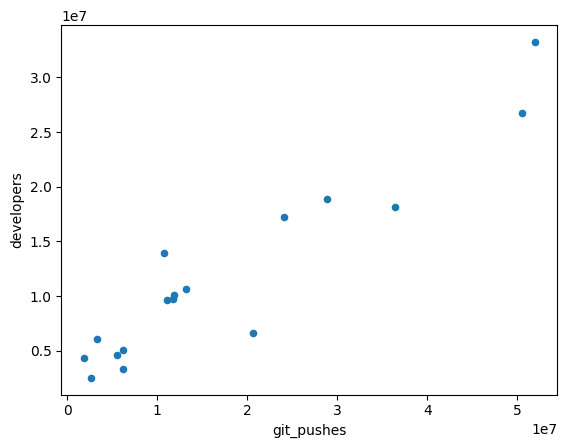

In [73]:
git_pushes_total = git_pushes.groupby(["iso2_code"])['git_pushes'].sum().reset_index().sort_values('git_pushes', ascending=False)
developers_total = developers.groupby(["iso2_code"])['developers'].sum().reset_index().sort_values('developers', ascending=False)

git_pushes_total.merge(developers_total, on="iso2_code", how="left").plot(x='git_pushes', y='developers', kind='scatter')

## Top GitHub Languages

The chart below shows the top 10 languages by number of GitHub pushers for Algeria and each peer country in the latest available quarter. Algeria is highlighted in blue; all peer countries are shown in grey.

In [74]:
clusters = pd.read_csv(GITHUB_DIR / "language_to_cluster_mapping.csv", sep=",")
clusters

,Language,Cluster,Cluster Name
0,AMPL,9,Specialized Tools
1,ANTLR,8,Text Parsing DSLs
2,ASP.NET,22,Enterprise OOP
3,ActionScript,31,Dynamic General Purpose
4,Ada,28,Strongly Typed Systems
...,...,...,...
137,Vue,1,JavaScript-Based Templating
138,XS,19,Low-Level Languages
139,XSLT,18,Low-Level Utilities
140,Yacc,8,Text Parsing DSLs


In [90]:
language_country_codes = [COUNTRY_CODE, "EG", "MA"]
language_country_order = [COUNTRY_NAMES[code] for code in language_country_codes]
language_country_colors = [ALGERIA_COLOR, "#FF9800", "#8A969F"]

languages = (
    pd.read_csv(GITHUB_DIR / "languages.csv")
    .loc[lambda d: d["iso2_code"].isin(language_country_codes)]
    .assign(
        quarter_start=lambda d: pd.PeriodIndex(
            d["year"].astype(str) + "Q" + d["quarter"].astype(str), freq="Q"
        ).to_timestamp(),
        country_name=lambda d: d["iso2_code"].map(COUNTRY_NAMES),
    )
)
languages["cluster"] = languages["language"].map(clusters.set_index("Language")["Cluster Name"])
languages = (
    languages
    .dropna(subset=["cluster"])
    .groupby(["iso2_code", "country_name", "cluster", "quarter_start", "year", "quarter"], as_index=False)["num_pushers"]
    .sum()
)
languages = attach_latest_population(languages, working_age_population).assign(
    num_pushers_per_100k=lambda d: d["num_pushers"] / d["working_age_population"] * 100_000
)
latest_language_quarter = languages["quarter_start"].max()
latest_language_rows = languages.loc[languages["quarter_start"] == latest_language_quarter].copy()
latest_language_label = (
    f"{latest_language_rows['year'].iloc[0]} Q{latest_language_rows['quarter'].iloc[0]}"
)

top_cluster_names = (
    latest_language_rows
    .sort_values(["country_name", "num_pushers_per_100k"], ascending=[True, False])
    .groupby("iso2_code", as_index=False, group_keys=False)
    .head(10)["cluster"]
    .drop_duplicates()
    .tolist()
)

language_comparison = (
    latest_language_rows
    .loc[lambda d: d["cluster"].isin(top_cluster_names)]
    .assign(num_pushers_label=lambda d: d["num_pushers"].map(lambda v: f"{v:,.0f}"))
)
cluster_sort = (
    language_comparison
    .groupby("cluster", as_index=False)["num_pushers_per_100k"]
    .sum()
    .sort_values("num_pushers_per_100k", ascending=False)["cluster"]
    .tolist()
)

language_bars = (
    alt.Chart(language_comparison)
    .mark_bar(size=8)
    .encode(
        x=alt.X("num_pushers_per_100k:Q", title="Pushers per 100k working-age population", axis=alt.Axis(format="~s")),
        y=alt.Y(
            "cluster:N",
            sort=cluster_sort,
            title=None,
            axis=alt.Axis(labelLimit=0),
        ),
        color=alt.Color(
            "country_name:N",
            title=None,
            scale=alt.Scale(domain=language_country_order, range=language_country_colors),
            legend=alt.Legend(orient="bottom", direction="horizontal"),
        ),
        yOffset=alt.YOffset("country_name:N", sort=language_country_order, scale=alt.Scale(paddingInner=0.45)),
        tooltip=[
            alt.Tooltip("country_name:N", title="Country"),
            alt.Tooltip("cluster:N", title="Cluster"),
            alt.Tooltip("num_pushers_per_100k:Q", title="Pushers per 100k", format=",.1f"),
            alt.Tooltip("num_pushers:Q", title="Pushers", format=","),
        ],
    )
)

languages_chart = language_bars.properties(
    width=620,
    height=max(320, 34 * len(cluster_sort)),
    title=alt.Title(
        text="Top GitHub Language Clusters in Algeria, Egypt, and Morocco",
        subtitle=f"Union of each country’s top 10 clusters by pushers per 100k working-age population, latest available quarter: {latest_language_label}",
        fontSize=14,
        subtitleFontSize=11,
        offset=10,
    ),
)

attaviz.add_caption(languages_chart, "Source: GitHub Innovation Graph languages data")




alt.VConcatChart(...)

In [91]:
languages_chart.save(
    "../../docs/images/ai_report/github_language_clusters.png",
    scale_factor=6,
)

## Algeria's Top GitHub Collaborators

GitHub's economic collaborator data records cross-economy collaboration weights. For Algeria, the chart below combines rows where Algeria is either the source or destination and ranks partner economies by total collaboration weight in the latest available quarter.

In [ ]:
collaborators = (
    pd.read_csv(GITHUB_DIR / "economy_collaborators.csv")
    .loc[lambda d: (d["source"] == COUNTRY_CODE) | (d["destination"] == COUNTRY_CODE)]
    .assign(
        quarter_start=lambda d: pd.PeriodIndex(
            d["year"].astype(str) + "Q" + d["quarter"].astype(str), freq="Q"
        ).to_timestamp(),
        partner_iso2=lambda d: d.apply(
            lambda row: row["destination"] if row["source"] == COUNTRY_CODE else row["source"],
            axis=1,
        ),
    )
)
latest_collab_quarter = collaborators["quarter_start"].max()
latest_collab_label = (
    f"{collaborators.loc[collaborators['quarter_start'] == latest_collab_quarter, 'year'].iloc[0]} "
    f"Q{collaborators.loc[collaborators['quarter_start'] == latest_collab_quarter, 'quarter'].iloc[0]}"
)

top_collaborators = (
    collaborators.loc[lambda d: d["quarter_start"] == latest_collab_quarter]
    .groupby("partner_iso2", as_index=False)["weight"]
    .sum()
    .assign(
        partner_name=lambda d: d["partner_iso2"].map(country_name_from_iso2),
        weight_label=lambda d: d["weight"].map(lambda v: f"{v:,.0f}"),
    )
    .sort_values("weight", ascending=False)
    .head(10)
)

y_sort = top_collaborators["partner_name"].tolist()
collab_bars = (
    alt.Chart(top_collaborators)
    .mark_bar(size=16)
    .encode(
        x=alt.X("weight:Q", title="Collaboration weight", axis=alt.Axis(format="~s")),
        y=alt.Y("partner_name:N", sort=y_sort, title=None),
        color=alt.value(ALGERIA_COLOR),
        tooltip=[
            alt.Tooltip("partner_name:N", title="Partner"),
            alt.Tooltip("partner_iso2:N", title="ISO2"),
            alt.Tooltip("weight:Q", title="Collaboration weight", format=","),
        ],
    )
)
collab_labels = (
    alt.Chart(top_collaborators)
    .mark_text(align="left", baseline="middle", dx=5, fontSize=11, color="#444")
    .encode(
        x=alt.X("weight:Q"),
        y=alt.Y("partner_name:N", sort=y_sort),
        text="weight_label:N",
    )
)

collaborators_chart = (collab_bars + collab_labels).properties(
    width=420,
    height=280,
    title=alt.Title(
        text="Top GitHub Collaborators for Algeria",
        subtitle=f"Latest available quarter: {latest_collab_label}",
        fontSize=14,
        subtitleFontSize=11,
        offset=10,
    ),
)

attaviz.add_caption(collaborators_chart, "Source: GitHub Innovation Graph economy collaborators data")

alt.VConcatChart(...)

In [97]:
# Keep EU as the Europe aggregate and drop individual European countries.
# Each panel shows US, EU, and the top three remaining non-European partners
# in the latest available 2025 quarter for that direction.
EXCLUDE_COLLABORATOR_PARTNERS = []

EUROPE_ISO2 = {
    "AL", "AD", "AT", "BY", "BE", "BA", "BG", "HR", "CY", "CZ", "DK", "EE",
    "FI", "FR", "DE", "GR", "HU", "IS", "IE", "IT", "XK", "LV", "LI", "LT",
    "LU", "MT", "MD", "MC", "ME", "NL", "MK", "NO", "PL", "PT", "RO", "RU",
    "SM", "RS", "SK", "SI", "ES", "SE", "CH", "UA", "GB", "VA",
}

excluded_partners = {code.upper() for code in EXCLUDE_COLLABORATOR_PARTNERS}
excluded_partners = excluded_partners | EUROPE_ISO2
excluded_partners.discard("EU")
required_partners = ["US", "EU"]


def prepare_algeria_collaborator_flow(flow: str) -> tuple[pd.DataFrame, list[str], str]:
    if flow == "Outbound":
        base = collaborators.loc[lambda d: d["source"] == COUNTRY_CODE].copy()
        partner_col = "destination"
    elif flow == "Inbound":
        base = collaborators.loc[lambda d: d["destination"] == COUNTRY_CODE].copy()
        partner_col = "source"
    else:
        raise ValueError("flow must be 'Outbound' or 'Inbound'")

    base = (
        base.loc[lambda d: ~d[partner_col].isin(excluded_partners)]
        .rename(columns={partner_col: "partner"})
        .groupby(["quarter_start", "year", "quarter", "partner"], as_index=False)["weight"]
        .sum()
    )

    latest_2025_quarter = base.loc[base["year"] == 2025, "quarter_start"].max()
    latest_2025_label = (
        base.loc[base["quarter_start"] == latest_2025_quarter, ["year", "quarter"]]
        .drop_duplicates()
        .assign(label=lambda d: d["year"].astype(str) + " Q" + d["quarter"].astype(str))
        ["label"]
        .iloc[0]
    )

    latest_partner_weights = (
        base.loc[lambda d: d["quarter_start"] == latest_2025_quarter]
        .groupby("partner", as_index=False)["weight"]
        .sum()
    )
    top_other_partners = (
        latest_partner_weights.loc[lambda d: ~d["partner"].isin(required_partners)]
        .sort_values("weight", ascending=False)
        .head(3)["partner"]
        .tolist()
    )
    selected_partners = required_partners + top_other_partners

    flow_data = (
        base.loc[lambda d: d["partner"].isin(selected_partners)]
        .assign(
            partner_name=lambda d: d["partner"].map(country_name_from_iso2),
            partner_order=lambda d: d["partner"].map(
                {code: i for i, code in enumerate(selected_partners)}
            ),
            flow=flow,
        )
    )
    partner_order = (
        flow_data.drop_duplicates("partner")
        .sort_values("partner_order")["partner_name"]
        .tolist()
    )
    return flow_data, partner_order, latest_2025_label


def make_collaborator_area_panel(flow: str, title: str) -> alt.Chart:
    flow_data, partner_order, latest_2025_label = prepare_algeria_collaborator_flow(flow)
    return (
        alt.Chart(flow_data)
        .mark_area(opacity=0.82)
        .encode(
            x=alt.X("quarter_start:T", title=None),
            y=alt.Y("weight:Q", title="Collaboration weight", stack="zero", axis=alt.Axis(format="~s", labelFontSize=8, titleFontSize=9)),
            color=alt.Color(
                "partner_name:N",
                title="Partner",
                scale=alt.Scale(domain=partner_order),
                legend=alt.Legend(orient="bottom", columns=3, labelFontSize=8, symbolSize=60),
            ),
            order=alt.Order("partner_order:Q", sort="ascending"),
            tooltip=[
                alt.Tooltip("partner_name:N", title="Partner"),
                alt.Tooltip("partner:N", title="ISO2"),
                alt.Tooltip("flow:N", title="Flow"),
                alt.Tooltip("year:O", title="Year"),
                alt.Tooltip("quarter:O", title="Quarter"),
                alt.Tooltip("weight:Q", title="Collaboration weight", format=","),
            ],
        )
        .properties(
            width=210,
            height=190,
            title=alt.Title(
                text=title,
                subtitle=f"US, EU, and top three non-European partners in {latest_2025_label}",
                fontSize=10,
                subtitleFontSize=8,
                offset=6,
            ),
        )
    )

outbound_collaborator_area = make_collaborator_area_panel("Outbound", "Outbound from Algeria")
inbound_collaborator_area = make_collaborator_area_panel("Inbound", "Inbound to Algeria")

collaborator_area_chart = alt.hconcat(
    outbound_collaborator_area,
    inbound_collaborator_area,
    spacing=18,
).resolve_scale(
    color="independent",
    y="independent",
).properties(
    title=alt.Title(text="GitHub Collaborator Flows for Algeria", fontSize=11, offset=8)
)

collaborator_area_chart = attaviz.add_caption(
    collaborator_area_chart,
    "Source: GitHub Innovation Graph economy collaborators data",
)
collaborator_area_chart




alt.VConcatChart(...)

In [98]:
collaborator_area_chart.save(
    "../../docs/images/ai_report/github_collaborator_flows.png", scale_factor=6)

## Top GitHub Collaborators for Peer Countries

The same bidirectional collaborator logic can be applied to every peer country. Each panel below shows the top 10 partner economies for one peer country in the latest available quarter.

In [93]:
peer_country_codes = [code for code in PEER_CODES if code != COUNTRY_CODE]

economy_collaborators = (
    pd.read_csv(GITHUB_DIR / "economy_collaborators.csv")
    .assign(
        quarter_start=lambda d: pd.PeriodIndex(
            d["year"].astype(str) + "Q" + d["quarter"].astype(str), freq="Q"
        ).to_timestamp()
    )
)
latest_peer_collab_quarter = economy_collaborators["quarter_start"].max()
latest_peer_collab_rows = economy_collaborators.loc[
    economy_collaborators["quarter_start"] == latest_peer_collab_quarter
].copy()
latest_peer_collab_label = (
    f"{latest_peer_collab_rows['year'].iloc[0]} Q{latest_peer_collab_rows['quarter'].iloc[0]}"
)

peer_partner_rows = []
for focal_iso2 in peer_country_codes:
    focal_rows = latest_peer_collab_rows.loc[
        (latest_peer_collab_rows["source"] == focal_iso2)
        | (latest_peer_collab_rows["destination"] == focal_iso2)
    ].copy()
    focal_rows["focal_iso2"] = focal_iso2
    focal_rows["partner_iso2"] = focal_rows.apply(
        lambda row: row["destination"] if row["source"] == focal_iso2 else row["source"],
        axis=1,
    )
    peer_partner_rows.append(focal_rows)

peer_top_collaborators = (
    pd.concat(peer_partner_rows, ignore_index=True)
    .groupby(["focal_iso2", "partner_iso2"], as_index=False)["weight"]
    .sum()
    .assign(
        focal_name=lambda d: d["focal_iso2"].map(COUNTRY_NAMES),
        partner_name=lambda d: d["partner_iso2"].map(country_name_from_iso2),
        weight_label=lambda d: d["weight"].map(lambda v: f"{v:,.0f}"),
    )
    .sort_values(["focal_name", "weight"], ascending=[True, False])
    .groupby("focal_iso2", as_index=False, group_keys=False)
    .head(10)
    .assign(rank=lambda d: d.groupby("focal_iso2")["weight"].rank(method="first", ascending=False).astype(int))
)

peer_collab_bars = (
    alt.Chart(peer_top_collaborators)
    .mark_bar(size=12)
    .encode(
        x=alt.X("weight:Q", title="Collaboration weight", axis=alt.Axis(format="~s")),
        y=alt.Y(
            "partner_name:N",
            sort=alt.SortField(field="weight", order="descending"),
            title=None,
            axis=alt.Axis(labelLimit=92),
        ),
        color=alt.value("#8A969F"),
        tooltip=[
            alt.Tooltip("focal_name:N", title="Country"),
            alt.Tooltip("partner_name:N", title="Partner"),
            alt.Tooltip("partner_iso2:N", title="Partner ISO2"),
            alt.Tooltip("weight:Q", title="Collaboration weight", format=","),
        ],
    )
)
peer_collab_labels = (
    alt.Chart(peer_top_collaborators)
    .mark_text(align="left", baseline="middle", dx=4, fontSize=9, color="#444")
    .encode(
        x=alt.X("weight:Q"),
        y=alt.Y(
            "partner_name:N",
            sort=alt.SortField(field="weight", order="descending"),
            title=None,
        ),
        text="weight_label:N",
    )
)

peer_collaborators_chart = (
    (peer_collab_bars + peer_collab_labels)
    .properties(width=170, height=150)
    .facet(
        facet=alt.Facet(
            "focal_name:N",
            title=None,
            sort=[COUNTRY_NAMES[code] for code in peer_country_codes],
            header=alt.Header(labelFontSize=12, labelFontWeight=600),
        ),
        columns=3,
    )
    .resolve_scale(x="independent", y="independent")
    .properties(
        title=alt.Title(
            text="Top GitHub Collaborators for Peer Countries",
            subtitle=f"Latest available quarter: {latest_peer_collab_label}",
            fontSize=14,
            subtitleFontSize=11,
            offset=10,
        )
    )
)

attaviz.add_caption(peer_collaborators_chart, "Source: GitHub Innovation Graph economy collaborators data")

KeyError: 'NG'

In [ ]:
open_router = pd.read_csv('../../data/ai/tokens_by_model_country_month_2026-02-25.csv')

In [ ]:
#open_router['model_permaslug'].unique()

In [ ]:
open_router

,month,model_permaslug,country,total_tokens,country_name
0,2026-02-01T00:00:00.000Z,minimax/minimax-m2.5-20260211,US,2314642206261,US
1,2026-02-01T00:00:00.000Z,moonshotai/kimi-k2.5-0127,US,1992602461455,US
2,2026-02-01T00:00:00.000Z,deepseek/deepseek-v3.2-20251201,US,1899669848004,US
3,2026-02-01T00:00:00.000Z,anthropic/claude-4.5-sonnet-20250929,US,1410529665496,US
4,2026-02-01T00:00:00.000Z,google/gemini-3-flash-preview-20251217,US,1272155713916,US
...,...,...,...,...,...
385927,2024-01-01T00:00:00.000Z,togethercomputer/stripedhyena-hessian-7b,NaN,1159781,NaN
385928,2024-01-01T00:00:00.000Z,nousresearch/nous-hermes-2-vision-7b,NaN,196524,NaN
385929,2024-01-01T00:00:00.000Z,openai/gpt-3.5-turbo-0613,NaN,116611,NaN
385930,2024-01-01T00:00:00.000Z,openai/text-davinci-002,NaN,78672,NaN


In [ ]:
open_router[open_router['country']=='DZ'].groupby(['model_permaslug'])['total_tokens'].sum().reset_index().sort_values('total_tokens', ascending=False).head(20)

,model_permaslug,total_tokens
90,deepseek/deepseek-chat-v3-0324,6195055680
474,tngtech/deepseek-r1t2-chimera,3548075950
493,xiaomi/mimo-v2-flash-20251210,2731231405
94,deepseek/deepseek-r1,2647370549
95,deepseek/deepseek-r1-0528,2639397139
91,deepseek/deepseek-chat-v3.1,2586379911
497,z-ai/glm-4.5-air,2123940224
416,qwen/qwen3-coder-480b-a35b-07-25,2064036017
170,kwaipilot/kat-coder-pro-v1,1757585018
489,x-ai/grok-4-fast,1718946320


In [ ]:
# --- Bar charts: Total tokens by country, grouped by peer group, always show Algeria (smaller subplot tiles) ---
def tokens_by_peer_group_with_algeria(df, peer_groups, country_names, country_code=COUNTRY_CODE):
    df['country_name'] = df['country'].map(country_names).fillna(df['country'])
    country_totals = df.groupby('country_name', as_index=False)['total_tokens'].sum()
    country_to_code = {v: k for k, v in country_names.items()}
    country_totals['iso2_code'] = country_totals['country_name'].map(lambda n: country_to_code.get(n, n))
    country_totals['peer_group'] = None
    for group, codes in peer_groups.items():
        for code in codes:
            name = country_names.get(code, code)
            country_totals.loc[country_totals['country_name'] == name, 'peer_group'] = group
    dz_name = country_names.get(country_code, country_code)
    dz_row = country_totals[country_totals['iso2_code'] == country_code].iloc[0]
    charts = []
    for group in ['Structural', 'Regional', 'Aspirational']:
        group_df = country_totals[country_totals['peer_group'] == group].copy()
        if dz_name not in group_df['country_name'].values:
            group_df = pd.concat([group_df, dz_row.to_frame().T], ignore_index=True)
        group_df['is_focal'] = group_df['iso2_code'] == country_code
        group_df['color'] = group_df['is_focal'].map(lambda x: ALGERIA_COLOR if x else '#8A969F')
        group_df = group_df.sort_values('total_tokens', ascending=False)
        chart = (
            alt.Chart(group_df)
            .mark_bar(size=14)
            .encode(
                x=alt.X('total_tokens:Q', title='Total Tokens'),
                y=alt.Y('country_name:N', sort='-x', title=None),
                color=alt.Color('color:N', scale=None, legend=None),
                tooltip=[
                    alt.Tooltip('country_name:N', title='Country'),
                    alt.Tooltip('total_tokens:Q', title='Total Tokens', format=',')
                ]
            )
            .properties(
                width=110,
                height=110,
                title=alt.Title(
                text=f'{group} Peers + Algeria',
                fontSize=12,           # <-- This controls the font size of the individual chart title
                subtitleFontSize=10  
            ))
        )
        charts.append(chart)
    panel = alt.hconcat(*charts, spacing=24).resolve_scale(x='independent', y='independent').properties(
        title=alt.Title(
            text='Total Tokens by Country (All Models, All Time)',
            subtitle='Grouped by Peer Group (Algeria always shown)',
            fontSize=12,
            subtitleFontSize=11,
            offset=10
        )
    )
    attaviz.add_caption(panel, 'Source: OpenRouter tokens_by_model_country_month_2026-02-25.csv')
    return panel

# Show the grouped bar chart with Algeria always included (smaller subplot tiles)
panel = tokens_by_peer_group_with_algeria(open_router, PEER_GROUPS, COUNTRY_NAMES, country_code=COUNTRY_CODE)
display(panel)


alt.HConcatChart(...)

In [ ]:
# --- Bar charts: Share of tokens by country, grouped by peer group, always show Algeria (smaller subplot tiles) ---
def tokens_share_by_peer_group_with_algeria(df, peer_groups, country_names, country_code=COUNTRY_CODE):
    df['country_name'] = df['country'].map(country_names).fillna(df['country'])
    country_totals = df.groupby('country_name', as_index=False)['total_tokens'].sum()
    total_tokens_all = country_totals['total_tokens'].sum()
    country_totals['share_tokens'] = country_totals['total_tokens'] / total_tokens_all
    country_to_code = {v: k for k, v in country_names.items()}
    country_totals['iso2_code'] = country_totals['country_name'].map(lambda n: country_to_code.get(n, n))
    country_totals['peer_group'] = None
    for group, codes in peer_groups.items():
        for code in codes:
            name = country_names.get(code, code)
            country_totals.loc[country_totals['country_name'] == name, 'peer_group'] = group
    dz_name = country_names.get(country_code, country_code)
    dz_row = country_totals[country_totals['iso2_code'] == country_code].iloc[0]
    charts = []
    for group in ['Structural', 'Regional', 'Aspirational']:
        group_df = country_totals[country_totals['peer_group'] == group].copy()
        if dz_name not in group_df['country_name'].values:
            group_df = pd.concat([group_df, dz_row.to_frame().T], ignore_index=True)
        group_df['is_focal'] = group_df['iso2_code'] == country_code
        group_df['color'] = group_df['is_focal'].map(lambda x: ALGERIA_COLOR if x else '#8A969F')
        group_df = group_df.sort_values('share_tokens', ascending=False)
        chart = (
            alt.Chart(group_df)
            .mark_bar(size=14)
            .encode(
                x=alt.X('share_tokens:Q', title='Share of Total Tokens', axis=alt.Axis(format='.2%')),
                y=alt.Y('country_name:N', sort='-x', title=None),
                color=alt.Color('color:N', scale=None, legend=None),
                tooltip=[
                    alt.Tooltip('country_name:N', title='Country'),
                    alt.Tooltip('share_tokens:Q', title='Share of Tokens', format='.2%'),
                    alt.Tooltip('total_tokens:Q', title='Total Tokens', format=',')
                ]
            )
            .properties(
                width=110,
                height=110,
                title=alt.Title(
                    text=f'{group} Peers + Algeria',
                    fontSize=12,
                    subtitleFontSize=10
                )
            )
        )
        charts.append(chart)
    panel = alt.hconcat(*charts, spacing=24).resolve_scale(x='independent', y='independent').properties(
        title=alt.Title(
            text='Share of Tokens by Country (All Models, All Time)',
            subtitle='Grouped by Peer Group (Algeria always shown)',
            fontSize=12,
            subtitleFontSize=11,
            offset=10
        )
    )
    attaviz.add_caption(panel, 'Source: OpenRouter tokens_by_model_country_month_2026-02-25.csv')
    return panel

# Show the grouped bar chart with Algeria always included (share of tokens)
panel = tokens_share_by_peer_group_with_algeria(open_router, PEER_GROUPS, COUNTRY_NAMES, country_code=COUNTRY_CODE)
display(panel)


alt.HConcatChart(...)

In [ ]:
# --- Bar charts: Share of tokens by country (global share), grouped by peer group, always show Algeria (smaller subplot tiles) ---
def tokens_global_share_by_peer_group_with_algeria(df, peer_groups, country_names, country_code=COUNTRY_CODE):
    df['country_name'] = df['country'].map(country_names).fillna(df['country'])
    country_totals = df.groupby('country_name', as_index=False)['total_tokens'].sum()
    total_tokens_global = country_totals['total_tokens'].sum()
    country_totals['share_tokens_global'] = country_totals['total_tokens'] / total_tokens_global
    country_to_code = {v: k for k, v in country_names.items()}
    country_totals['iso2_code'] = country_totals['country_name'].map(lambda n: country_to_code.get(n, n))
    country_totals['peer_group'] = None
    for group, codes in peer_groups.items():
        for code in codes:
            name = country_names.get(code, code)
            country_totals.loc[country_totals['country_name'] == name, 'peer_group'] = group
    dz_name = country_names.get(country_code, country_code)
    dz_row = country_totals[country_totals['iso2_code'] == country_code].iloc[0]
    charts = []
    for group in ['Structural', 'Regional', 'Aspirational']:
        group_df = country_totals[country_totals['peer_group'] == group].copy()
        if dz_name not in group_df['country_name'].values:
            group_df = pd.concat([group_df, dz_row.to_frame().T], ignore_index=True)
        group_df['is_focal'] = group_df['iso2_code'] == country_code
        group_df['color'] = group_df['is_focal'].map(lambda x: ALGERIA_COLOR if x else '#8A969F')
        group_df = group_df.sort_values('share_tokens_global', ascending=False)
        chart = (
            alt.Chart(group_df)
            .mark_bar(size=14)
            .encode(
                x=alt.X('share_tokens_global:Q', title='Share of Global Tokens', axis=alt.Axis(format='.2%')),
                y=alt.Y('country_name:N', sort='-x', title=None),
                color=alt.Color('color:N', scale=None, legend=None),
                tooltip=[
                    alt.Tooltip('country_name:N', title='Country'),
                    alt.Tooltip('share_tokens_global:Q', title='Share of Global Tokens', format='.2%'),
                    alt.Tooltip('total_tokens:Q', title='Total Tokens', format=',')
                ]
            )
            .properties(
                width=110,
                height=110,
                title=alt.Title(
                    text=f'{group} Peers + Algeria',
                    fontSize=12,
                    subtitleFontSize=10
                )
            )
        )
        charts.append(chart)
    panel = alt.hconcat(*charts, spacing=24).resolve_scale(x='independent', y='independent').properties(
        title=alt.Title(
            text='Share of Global Tokens by Country (All Models, All Time)',
            subtitle='Grouped by Peer Group (Algeria always shown)',
            fontSize=12,
            subtitleFontSize=11,
            offset=10
        )
    )
    attaviz.add_caption(panel, 'Source: OpenRouter tokens_by_model_country_month_2026-02-25.csv')
    return panel

# Show the grouped bar chart with Algeria always included (global share of tokens)
panel = tokens_global_share_by_peer_group_with_algeria(open_router, PEER_GROUPS, COUNTRY_NAMES, country_code=COUNTRY_CODE)
display(panel)


In [ ]:
# --- Altair scatter plot: Total Git pushes vs. Total Developers by country, using attaviz style ---
merged_totals = git_pushes_total.merge(developers_total, on="iso2_code", how="left")
merged_totals['country_name'] = merged_totals['iso2_code'].map(COUNTRY_NAMES).fillna(merged_totals['iso2_code'])
merged_totals['is_algeria'] = merged_totals['iso2_code'] == COUNTRY_CODE

scatter = (
    alt.Chart(merged_totals)
    .mark_circle(size=80, opacity=0.85)
    .encode(
        x=alt.X('git_pushes:Q', title='Total Git Pushes', scale=alt.Scale(type='log')),  # log scale for spread
        y=alt.Y('developers:Q', title='Total Developers', scale=alt.Scale(type='log')),
        color=alt.condition(
            alt.datum.is_algeria,
            alt.value(ALGERIA_COLOR),
            alt.value('#8A969F')
        ),
        tooltip=[
            alt.Tooltip('country_name:N', title='Country'),
            alt.Tooltip('git_pushes:Q', title='Total Git Pushes', format=','),
            alt.Tooltip('developers:Q', title='Total Developers', format=',')
        ]
    )
    .properties(
        width=340,
        height=320,
        title=alt.Title(
            text='Total Git Pushes vs. Total Developers by Country',
            subtitle='Each point is a country; Algeria highlighted',
            fontSize=14,
            subtitleFontSize=11,
            offset=10
        )
    )
)
attaviz.add_caption(scatter, 'Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO')
display(scatter)


alt.Chart(...)

In [101]:
# --- Altair scatter plot: Pushes per developer vs. avg developers per avg working age population, using attaviz style ---
# Include Kenya for this comparison, even though it is not part of the standard peer set.
scatter_country_codes = sorted(set(PEER_CODES + ["KE", "NG"]))
highlight_country_codes = [COUNTRY_CODE, "EG", "KE", "NG", "MA"]
highlight_country_names = [country_name_from_iso2(code) for code in highlight_country_codes]
highlight_colors = [ALGERIA_COLOR, "#FF9800", "#0C7C68", "#F3578E", "#664AB6"]

scatter_developers = load_github_metric(
    "developers",
    working_age_population,
    peer_codes=scatter_country_codes,
)
scatter_git_pushes = load_github_metric(
    "git_pushes",
    working_age_population,
    peer_codes=scatter_country_codes,
)

developers_total_scatter = (
    scatter_developers.groupby("iso2_code", as_index=False)["developers"]
    .sum()
    .sort_values("developers", ascending=False)
)
git_pushes_total_scatter = (
    scatter_git_pushes.groupby("iso2_code", as_index=False)["git_pushes"]
    .sum()
    .sort_values("git_pushes", ascending=False)
)

avg_devs = (
    scatter_developers.groupby("iso2_code", as_index=False)["developers"]
    .mean()
    .rename(columns={"developers": "avg_developers"})
)
avg_working_age_pop = (
    working_age_population.loc[lambda d: d["iso2_code"].isin(scatter_country_codes)]
    .groupby("iso2_code", as_index=False)["working_age_population"]
    .mean()
    .rename(columns={"working_age_population": "avg_working_age_population"})
)

merged = git_pushes_total_scatter.merge(developers_total_scatter, on="iso2_code", how="left")
merged = merged.merge(avg_devs, on="iso2_code", how="left")
merged = merged.merge(avg_working_age_pop, on="iso2_code", how="left")
merged["country_name"] = merged["iso2_code"].map(COUNTRY_NAMES).fillna(
    merged["iso2_code"].map(country_name_from_iso2)
)
merged["highlight_group"] = merged["iso2_code"].where(
    merged["iso2_code"].isin(highlight_country_codes),
    other="Other",
)
merged["highlight_name"] = merged["iso2_code"].map(
    {code: country_name_from_iso2(code) for code in highlight_country_codes}
)

merged["pushes_per_developer"] = merged["git_pushes"] / merged["developers"]
merged["avg_devs_per_avg_100k_pop"] = merged["avg_developers"] / (
    merged["avg_working_age_population"] / 100_000
)
plot_df = merged.dropna(subset=["pushes_per_developer", "avg_devs_per_avg_100k_pop"])

base = alt.Chart(plot_df).encode(
    x=alt.X(
        "avg_devs_per_avg_100k_pop:Q",
        title="Avg developers per 100k working-age population",
        scale=alt.Scale(type="log"),
    ),
    y=alt.Y(
        "pushes_per_developer:Q",
        title="Pushes per developer",
        scale=alt.Scale(type="log"),
    ),
)

points = base.mark_circle(size=85, opacity=0.85).encode(
    color=alt.Color(
        "highlight_group:N",
        title=None,
        scale=alt.Scale(
            domain=["Other"] + highlight_country_codes,
            range=["#8A969F"] + highlight_colors,
        ),
        legend=alt.Legend(
            orient="bottom",
            direction="horizontal",
            labelExpr="datum.label == 'Other' ? 'Other' : {'DZ': 'Algeria', 'EG': 'Egypt', 'KE': 'Kenya', 'NG': 'Nigeria', 'MA': 'Morocco'}[datum.label]",
        ),
    ),
    tooltip=[
        alt.Tooltip("country_name:N", title="Country"),
        alt.Tooltip("avg_devs_per_avg_100k_pop:Q", title="Avg devs per 100k avg pop", format=".2f"),
        alt.Tooltip("pushes_per_developer:Q", title="Pushes per developer", format=".2f"),
        alt.Tooltip("git_pushes:Q", title="Total git pushes", format=","),
        alt.Tooltip("developers:Q", title="Total developers", format=","),
        alt.Tooltip("avg_developers:Q", title="Avg developers", format=","),
        alt.Tooltip("avg_working_age_population:Q", title="Avg working-age population", format=","),
    ],
)

labels = base.transform_filter(
    alt.datum.highlight_group != "Other"
).mark_text(
    align="left",
    baseline="middle",
    dx=7,
    fontSize=11,
    color="#111111",
).encode(
    text="country_name:N",
)

scatter = (points + labels).properties(
    width=340,
    height=320,
    title=alt.Title(
        text="Developers and Git Push Intensity by Country",
        subtitle="Egypt, Kenya, Nigeria, Morocco, and Algeria highlighted",
        fontSize=14,
        subtitleFontSize=11,
        offset=10,
    ),
)

attaviz.add_caption(scatter, "Source: GitHub Innovation Graph data; World Bank SP.POP.1564.TO")
display(scatter)




alt.LayerChart(...)

In [102]:
scatter.save(
    "../../docs/images/ai_report/pushes_per_developer_scatter.png",
    scale_factor=6,
)

In [103]:
# --- Altair scatter plot: OpenRouter average monthly tokens vs. developers per 100k avg working age population ---
# Calculate average monthly tokens per country
open_router['month'] = pd.to_datetime(open_router['year'].astype(str) + '-' + open_router['month'].astype(str).str.zfill(2) + '-01') if 'month' in open_router.columns else None
monthly_tokens = open_router.groupby(['country', 'year', 'month'], as_index=False)['total_tokens'].sum()
avg_monthly_tokens = monthly_tokens.groupby('country', as_index=False)['total_tokens'].mean().rename(columns={'total_tokens': 'avg_monthly_tokens'})
avg_monthly_tokens['iso2_code'] = avg_monthly_tokens['country']

# Merge with avg_devs and avg_working_age_pop
merged_tokens_devs_pop = avg_monthly_tokens.merge(avg_devs, on='iso2_code', how='left').merge(avg_working_age_pop, on='iso2_code', how='left')
merged_tokens_devs_pop['country_name'] = merged_tokens_devs_pop['iso2_code'].map(COUNTRY_NAMES).fillna(merged_tokens_devs_pop['iso2_code'])
merged_tokens_devs_pop['is_algeria'] = merged_tokens_devs_pop['iso2_code'] == COUNTRY_CODE
merged_tokens_devs_pop['avg_devs_per_avg_100k_pop'] = merged_tokens_devs_pop['avg_developers'] / (merged_tokens_devs_pop['avg_working_age_population'] / 100_000)

scatter2 = (
    alt.Chart(merged_tokens_devs_pop)
    .mark_circle(size=80, opacity=0.85)
    .encode(
        x=alt.X('avg_devs_per_avg_100k_pop:Q', title='Avg Developers per 100k Avg Working Age Population', scale=alt.Scale(type='log')),
        y=alt.Y('avg_monthly_tokens:Q', title='Avg Monthly OpenRouter Tokens', scale=alt.Scale(type='log')),
        color=alt.condition(
            alt.datum.is_algeria,
            alt.value(ALGERIA_COLOR),
            alt.value('#8A969F')
        ),
        tooltip=[
            alt.Tooltip('country_name:N', title='Country'),
            alt.Tooltip('avg_devs_per_avg_100k_pop:Q', title='Avg Devs per 100k Avg Pop', format='.2f'),
            alt.Tooltip('avg_monthly_tokens:Q', title='Avg Monthly OpenRouter Tokens', format=',')
        ]
    )
    .properties(
        width=340,
        height=320,
        title=alt.Title(
            text='Avg Monthly OpenRouter Tokens vs. Avg Devs per 100k Avg Pop by Country',
            subtitle='Each point is a country; Algeria highlighted',
            fontSize=14,
            subtitleFontSize=11,
            offset=10
        )
    )
)
attaviz.add_caption(scatter2, 'Source: OpenRouter tokens_by_model_country_month_2026-02-25.csv; GitHub Innovation Graph; World Bank SP.POP.1564.TO')
display(scatter2)

NameError: name 'open_router' is not defined